In [1]:
import Agents
import MarketsV03 as Markets

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

In [2]:
epsilon = 0.005
theta = 0.1

NA = 50
NB = 50
N = NA+NB

initialize_money = 'set'
M = 100.

n = 2

QA1 = 0.
QA2 = 0.

qA1 = 5.
qA2 = 0.

cA1 = 0.
cA2 = 5.

QB1 = 0.
QB2 = 0.

qB1 = 0.
qB2 = 5.

cB1 = 5.
cB2 = 0.

QA_0 = np.array([QA1, QA2])
QB_0 = np.array([QB1, QB2])

QA = np.copy(QA_0)
QB = np.copy(QB_0)

qA = np.array([qA1, qA2])
qB = np.array([qB1, qB2])

cA = np.array([cA1, cA2])
cB = np.array([cB1, cB2])

DA = cA.copy()
DB = cB.copy()

initialize_prices = 'set'

p1buy_A_0    = 0. 
p1sell_A_0   = 1.

p2buy_A_0    = 0.
p2sell_A_0   = 0. 

p1buy_B_0    = 1.
p1sell_B_0   = 0. 

p2buy_B_0    = 0.
p2sell_B_0   = 0.

In [3]:
def add_price_data(df, t):
    
    p_buy, p_sell = df
    
    for v, agent in enumerate(agent_list):
        p_buy[t][v] = agent.p_buy
        p_sell[t][v] = agent.p_sell
        
def add_quant_data(df, t):

    for v,agent in enumerate(agent_list):

        df[t][v] = agent.Q
    
def add_deficit_data(df, t):

    for v,agent in enumerate(agent_list):

        df[t][v] = agent.D
    
def add_money_data(df, t):
    
    for v,agent in enumerate(agent_list):

        df[t][v] = agent.M

In [4]:
def reset():
    
    for agent in agentA_list:
        
        if initialize_prices=='random':
            
            agent.p_buy  = np.random.uniform(agent.M, size=n)
            agent.p_sell = np.random.uniform(agent.M, size=n)
            
        else:
            agent.p_buy  = [p1buy_A_0, p2buy_A_0]
            agent.p_sell = [p1sell_A_0, p2sell_A_0]
        
    for agent in agentB_list:
        
        if initialize_prices=='random':
            agent.p_buy  = np.random.uniform(agent.M, size=n)
            agent.p_sell = np.random.uniform(agent.M, size=n)
        
        else:
            agent.p_buy  = [p1buy_B_0, p2buy_B_0]
            agent.p_sell = [p1sell_B_0, p2sell_B_0]
            
def market_supply_demand(i):
    supply0 = 0
    demand0 = 0
    for agent in agent_list:

        quants = scda.determine_market_quantity(agent)

        if quants[i] > 0:
            supply0 += quants[i]
        elif quants[i] < 0:
            demand0 += -quants[i]
            
    return supply0, demand0

In [5]:
agentA_list = [Agents.Agent(QA.copy(), DA.copy(), M, n_actions=1, input_dims=[1]) for v in range(NA)]
agentB_list = [Agents.Agent(QB.copy(), DB.copy(), M, n_actions=1, input_dims=[1]) for v in range(NB)]

agent_list = agentA_list + agentB_list

In [6]:
M_dict = {}

for agent in agent_list:
    
    M_dict[agent] = np.random.uniform(M)

In [7]:
M_total = 0
for agent in agent_list:
    M_total += agent.M
    
M_total

10000.0

In [8]:
# Initialize agent asking and bidding prices

In [9]:
max_tries = 100 #3 #1*N #1

In [10]:
scda = Markets.SCDA(n, theta=theta, gamma=1.0, epsilon=0.01, max_tries=max_tries, M_min=0.01, peval='log_mean')
ExchangeDict = {agent : 2 for agent in agent_list}

In [11]:
def randomize_prices():

    for agent in agent_list:

        if random.random() < epsilon:
            agent.p_buy = np.random.uniform(0, agent.M, n)

        if random.random() < epsilon:
            agent.p_sell = np.random.uniform(0, agent.M, n)

In [12]:
T = 100

reset()

# Setup data
p_buy, p_sell = np.zeros((T, N, n)), np.zeros((T, N, n))
p_df = (p_buy, p_sell)

Q_df = np.zeros((T, N, n))
D_df = np.zeros((T, N, n))
M_df = np.zeros((T, N))

# Setup data
ME_df = np.zeros((T-1,n))
QE_df = np.zeros((T-1,n))
ntries_df = []
    
supply_df = []
demand_df = []

add_price_data(p_df, 0)
add_quant_data(Q_df, 0)
add_deficit_data(D_df, 0)
add_money_data(M_df, 0)

Q__ = QA.copy()

# Run market
for t in range(T-1):
    
    if t % 100 == 0:
        print(t)

    supply0_t, demand0_t = market_supply_demand(0)
    supply1_t, demand1_t = market_supply_demand(1)
    
    supply_t = [supply0_t, supply1_t]
    demand_t = [demand0_t, demand1_t]

    # Market action occurs at half-time interval
    ME, QE, ntries = scda.run_exchange(ExchangeDict)

    # Reset quantities
    for agentA in agentA_list:

        agentA.D = agentA.D + cA
        agentA.Q = np.maximum(0, agentA.Q + qA - np.minimum(agentA.Q, agentA.D))
        

    for agentB in agentB_list:

        agentB.D = agentB.D + cB
        agentB.Q = np.maximum(0, agentB.Q + qB - np.minimum(agentB.Q, agentB.D))
        
    add_price_data(p_df, t+1)
    add_quant_data(Q_df, t+1)
    add_deficit_data(D_df, t)
    add_money_data(M_df, t)

    # Market action occurs at half-time interval
    ME_df[t] = ME
    QE_df[t] = QE
    ntries_df.append(ntries)

    supply_df.append(supply_t)
    demand_df.append(demand_t)
    
    randomize_prices()

p = ME_df/QE_df

supply_df = np.array(supply_df)
demand_df = np.array(demand_df)

0


C:\Users\Alex\AppData\Local\Temp\ipykernel_16120\174368686.py:70: RuntimeWarning: invalid value encountered in divide
  p = ME_df/QE_df


Plotting

In [13]:
np.nanmean(p, axis=0)

array([0.40775976, 0.25919402])

In [14]:
def plot_market(i, *, ps=10, log=False, supply_demand=False, show_M_total=False):

    f, ax = plt.subplots(1, figsize=(10,4)) #(2,1)

    ax.plot(ME_df[:,i], c='C0', label=f'$\Delta M_{i}$')
    ax.plot(QE_df[:,i], c='C1', label=f'$\Delta Q_{i}$')
    ax.plot(ntries_df, c='k', label='Tries', lw='0.5')

    #ax.scatter(np.arange(0,T-1), p[:,i], c='g', label=f'$p_{i}$', s=ps)
    ax.plot(p[:,i], c='g', label=f'$p_{i}$')
    
    if supply_demand:
        ax.plot(supply_df[:,i], c='blue', ls='--', label=f'Supply')
        ax.plot(demand_df[:,i], c='orange', ls='--', label=f'Demand')
        
    if show_M_total:
        ax.axhline(M_total, c='g', ls=':', label='$M_{total}$')

    ax.legend(bbox_to_anchor=(1, 0.5))
    
    if log:
        plt.yscale('log')
        
    plt.title(f'Market for Commodity {i}')
    plt.xlabel('t')
    plt.ylabel('$M$, $Q$')

In [15]:
def plot_prices(i, *, log=False):

    p_buy, p_sell = p_df[0], p_df[1]

    lw = 1.0

    for n in range(NA):
        plt.plot(p_sell[:,n][:,i], c='C1', lw=lw/5.)
    plt.plot(M_df[:-1, 0:NA].sum(axis=1), c='g', ls='-')

    for n in range(NB):
        plt.plot(p_buy[:,NA+n][:,i], c='C0', lw=lw/5.)
    plt.plot(M_df[:-1, NA:].sum(axis=1), c='lime', ls='-')

    plt.plot(p[:,i], c='g', lw=lw)
    plt.ylim(ymin=0.007)

    plt.title(f'Commodity {i}. Blue Bidding Price. Orange Asking Price')
    if log:
        plt.yscale('log')

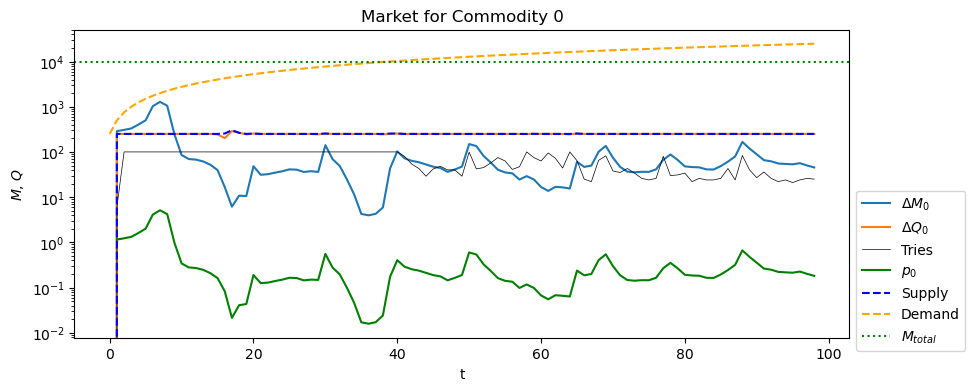

In [16]:
plot_market(0, log=True, supply_demand=True, show_M_total=True)
#plt.ylim(ymin=0.007, ymax=2e4)
plt.show()

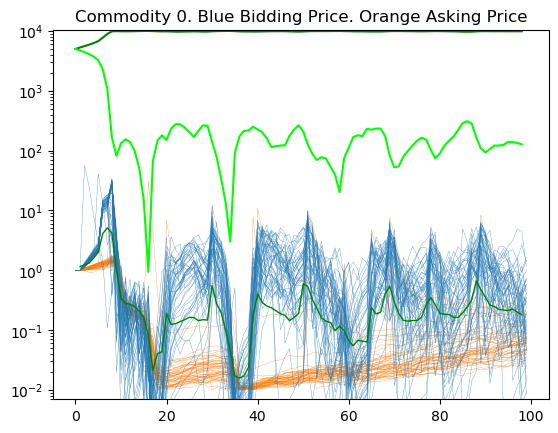

In [17]:
plot_prices(0, log=True)

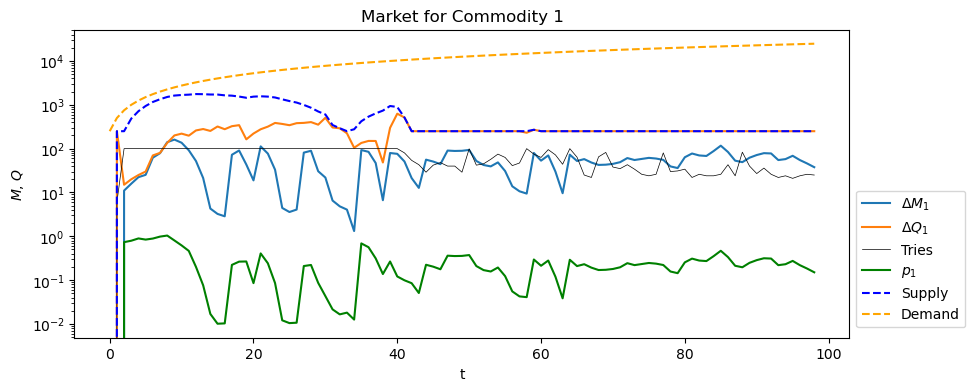

In [18]:
plot_market(1, log=True, supply_demand=True, show_M_total=False)
#plt.ylim(ymin=0.007, ymax=2e4)
plt.show()

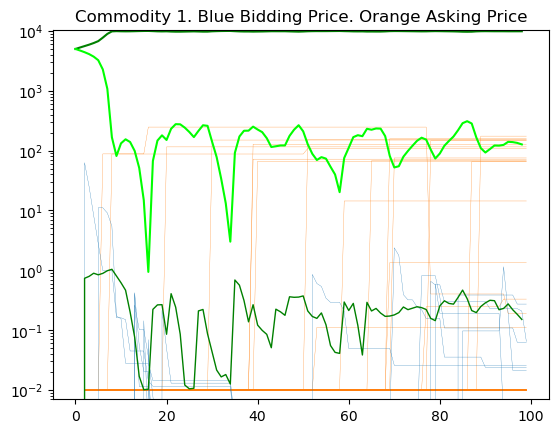

In [19]:
plot_prices(1, log=True)

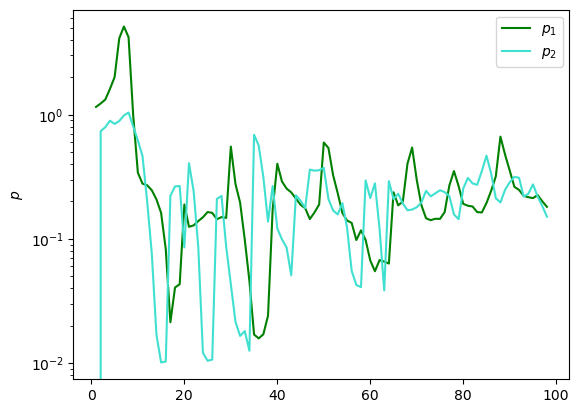

In [20]:
plt.plot(p[:,0], c='g', label='$p_1$')
plt.plot(p[:,1], c='turquoise', label='$p_2$')
plt.ylabel('$p$')
plt.yscale('log')
plt.legend()

C:\Users\Alex\AppData\Local\Temp\ipykernel_16120\1150479661.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(p[:,0]/p[:,1], c='g')


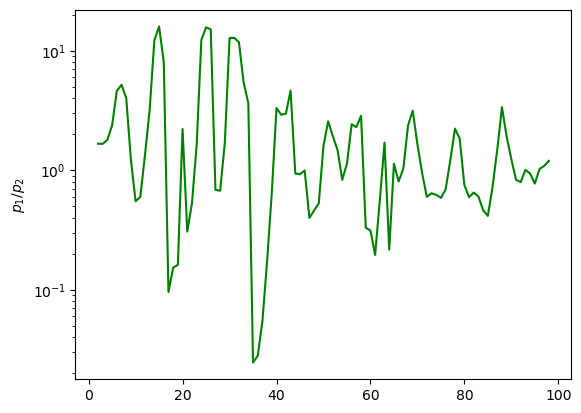

In [21]:
plt.plot(p[:,0]/p[:,1], c='g')
plt.ylabel('$p_{1}/p_{2}$')
plt.yscale('log')

C:\Users\Alex\AppData\Local\Temp\ipykernel_16120\3589480324.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.hist(p[:,0]/p[:,1], color='k', histtype='step')


ValueError: supplied range of [0.024668181899916486, inf] is not finite

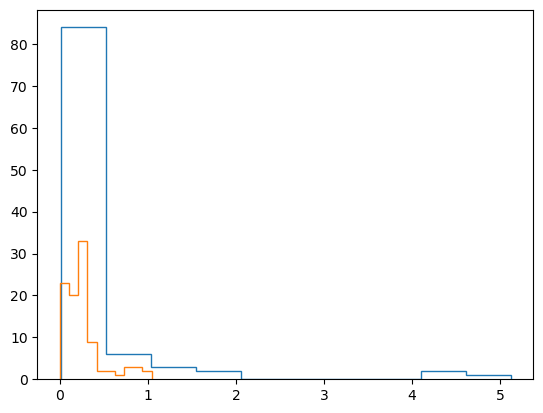

In [22]:
plt.hist(p[:,0], color='C0', histtype='step')
plt.hist(p[:,1], color='C1', histtype='step')
plt.hist(p[:,0]/p[:,1], color='k', histtype='step')

In [ ]:
assert False

In [ ]:
#ME_df

In [ ]:
#QE_df

In [ ]:
x_data=[]
xx_data=[]

B = 10000

theta = 0.01

x = 1

for _ in range(B):
    

    th = np.random.choice([-theta, theta])
    
    x *= (1+th)
    x_data.append(x)
    
    theta2 = theta #theta/(1+theta)
    
    xx = (1+theta)**_ * (1-theta2)**_
    
    xx_data.append(xx)

x_data=np.array(x_data)
xx_data=np.array(xx_data)


In [ ]:
xx

In [ ]:
plt.plot(x_data)

In [ ]:
plt.plot(xx_data)



In [ ]:
def randomize_agent_bid(agent, i):
    
    #new_bid = np.random.uniform(M_min, agent.M)
    new_bid = random_bid_list[eps_agent_list < epsilon]
    agent.p_buy[i] = new_bid
    
def randomize_agent_ask(agent, i):
    
    new_ask = np.random.uniform(M_min, agent.M)
    agent.p_sell[i] = new_ask
    
epsilon = 1e-2
eps_agent_list = np.random.uniform(0,1, Nm)

    
bid_dist_i = agent_data[:, 0, i]

mean_bid = bid_dist_i.mean()
std_bid = bid_dist_i.std()

random_bid_list = std_bid/2.*np.random.standard_cauchy(Nm) + mean_bid

[randomize_agent_bid(agent, i) for agent in exchanging_agent_list[eps_agent_list < epsilon]]